<a href="https://colab.research.google.com/github/hyui02/ESAA_assignment/blob/main/1stminiproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ESAA 미니프로젝트 — 시각화 후보 (계절 / 감독 / 관람등급)

DACON 영화 관객수 데이터(2010~2015년 한국영화 600편)로 세 가지 주제를 단계적으로 검증한다.

| | 주제 | 결론 |
|---|---|---|
| 계절 | 계절/월별 개봉과 흥행의 관계 | 겨울이 아니라 1월 효과이며, 대부분 제작 규모로 설명된다 |
| 감독 | 감독 경력이 흥행을 만드는가 | 대부분 제작 규모로 설명되며, 변수 자체의 신뢰성도 낮다 |
| 관람등급 | 청소년 관람불가 비율의 변화 | 2013년을 기점으로 수준이 이동했고, 대부분 장르 내부 변화로 설명된다 |

## 0. 준비
- 데이터 불러오기, 공통된 전처리 등을 진행한 단계이다

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

train = pd.read_csv('/content/movies_train.csv')
print(train.shape)
train.head()

(600, 12)


,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [2]:
# 코랩 한글 폰트 (한 번만 실행)
!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'NanumGothic'   # seaborn이 폰트를 덮으므로 set_style 뒤에
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 전처리 (세 주제 공통)
train['release_time'] = pd.to_datetime(train['release_time'])
train['release_year'] = train['release_time'].dt.year
train['release_month'] = train['release_time'].dt.month

train['dir_prev_bfnum'] = train['dir_prev_bfnum'].fillna(0)
train['director_type'] = np.where(train['dir_prev_num'] == 0, '신인', '경력')

train['scale'] = pd.cut(train['num_staff'], [-1, 80, 250, 900],
                         labels=['소(~80명)', '중(81~250명)', '대(251명~)'])
train['log_box_off_num'] = np.log10(train['box_off_num'])

season_map = {12: '겨울', 1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄',
              6: '여름', 7: '여름', 8: '여름', 9: '가을', 10: '가을', 11: '가을'}
train['season'] = train['release_month'].map(season_map)
season_order = ['봄', '여름', '가을', '겨울']
scale_order = ['소(~80명)', '중(81~250명)', '대(251명~)']

train[['title', 'release_year', 'release_month', 'season', 'scale']].head()

,title,release_year,release_month,season,scale
0,개들의 전쟁,2012,11,가을,중(81~250명)
1,내부자들,2015,11,가을,대(251명~)
2,은밀하게 위대하게,2013,6,여름,대(251명~)
3,나는 공무원이다,2012,7,여름,소(~80명)
4,불량남녀,2010,11,가을,대(251명~)


---
# 2번. 계절에 따라 관객수가 달라지는가

**가설**: 개봉 계절에 따라 흥행에 차이가 있을 것이다. 특히 여름은 무더위 속 실내 관람 수요와 방학이 겹쳐 관객이 몰릴 것으로 예상했다.

### **1단계. 계절별 관객수**

관객수는 소수의 흥행작이 분포를 오른쪽으로 치우치게 하므로 중앙값으로 비교한다.

In [4]:
season_stat = train.groupby('season')['box_off_num'].agg(n_films='size', box_median='median').loc[season_order]
print(season_stat)

kw_p = stats.kruskal(*[train[train['season'] == s]['box_off_num'] for s in season_order]).pvalue
print('크러스컬-왈리스 검정 p:', round(kw_p, 3))

        n_films  box_median
season                     
봄           156      5942.5
여름          133     13886.0
가을          192     18618.5
겨울          119     27083.0
크러스컬-왈리스 검정 p: 0.028


계절 4분류로 나눠 관객수 중앙값을 비교하면 봄 5,943명, 여름 13,886명, 가을 18,619명, 겨울 27,083명으로 겨울이 가장 높다. 관객수 분포가 오른쪽으로 치우쳐 있어 중앙값을 기준으로 비교했고, 이 차이가 우연인지 크러스컬-왈리스 검정으로 확인한 결과 p=0.028로 0.05보다 작아 통계적으로 유의하다.

다만 겨울 안에서 어떤 달이 이 차이를 만드는지는 아직 알 수 없다. 다음 단계에서 월 단위로 나눠 확인한다.

### **2단계. 겨울의 높은 관객수는 어디서 오는가**

겨울(12·1·2월) 중 어떤 달이 이 차이를 만드는지 월별로 나눠 확인한다.

In [5]:
month_stat = train.groupby('release_month')['box_off_num'].agg(n_films='size', box_median='median')
print(month_stat.sort_values('box_median', ascending=False))

               n_films  box_median
release_month                     
1                   39    283449.0
10                  60     45112.0
6                   29     18343.0
8                   55     16248.0
11                  72     15813.0
9                   60     14931.0
2                   31     10203.0
12                  49      9323.0
7                   49      9301.0
4                   47      7956.0
5                   57      7448.0
3                   52      4110.5


12개 월을 관객수 중앙값이 높은 순으로 나열하면 1월(283,449명)이 2위인 10월(45,112명)보다도 6배 이상 높아, 나머지 11개월과 뚜렷이 떨어져 있다. 1월만 유독 이렇게 다르므로, 이후 분석은 "겨울" 전체가 아니라 1월을 기준으로 좁혀서 진행한다.

참고로 겨울에 속하는 12월(9,323명, 12개월 중 8위)과 2월(10,203명, 7위)은 오히려 중하위권이다. "겨울"이라는 계절 구분 자체가 1월의 효과를 12·2월과 뭉뚱그려서 가려온 셈이다.

In [6]:
jan = train[train['release_month'] == 1]['box_off_num']
not_jan = train[train['release_month'] != 1]['box_off_num']

print('1월:', len(jan), '편, 중앙값', jan.median(), '명')
print('1월이 아닌 달:', len(not_jan), '편, 중앙값', not_jan.median(), '명')
print('p값:', round(stats.mannwhitneyu(jan, not_jan).pvalue, 3))

1월: 39 편, 중앙값 283449.0 명
1월이 아닌 달: 561 편, 중앙값 11650.0 명
p값: 0.027


1월(39편)의 관객수 중앙값은 283,449명으로, 1월이 아닌 달(561편, 중앙값 11,650명)보다 24배 높다. 이 차이는 통계적으로 유의하다(p=0.027).

In [7]:
dec_feb = train[train['release_month'].isin([12, 2])]['box_off_num']
non_winter = train[train['season'] != '겨울']['box_off_num']

print('12·2월:', len(dec_feb), '편, 중앙값', dec_feb.median(), '명')
print('겨울이 아닌 달:', len(non_winter), '편, 중앙값', non_winter.median(), '명')
print('p값:', round(stats.mannwhitneyu(dec_feb, non_winter).pvalue, 3))

12·2월: 80 편, 중앙값 9763.0 명
겨울이 아닌 달: 481 편, 중앙값 11666.0 명
p값: 0.187


반면 12·2월(겨울에서 1월을 뺀 나머지)은 겨울이 아닌 달과 관객수 차이가 없다(p=0.187, 유의하지 않음). 즉 1단계에서 본 "겨울이 높다"는 결과는 겨울 전체가 아니라 1월 한 달이 만든 것이다.

/tmp/ipykernel_36676/1748760806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=month_stat.index, y=month_stat['box_median'], palette=colors)


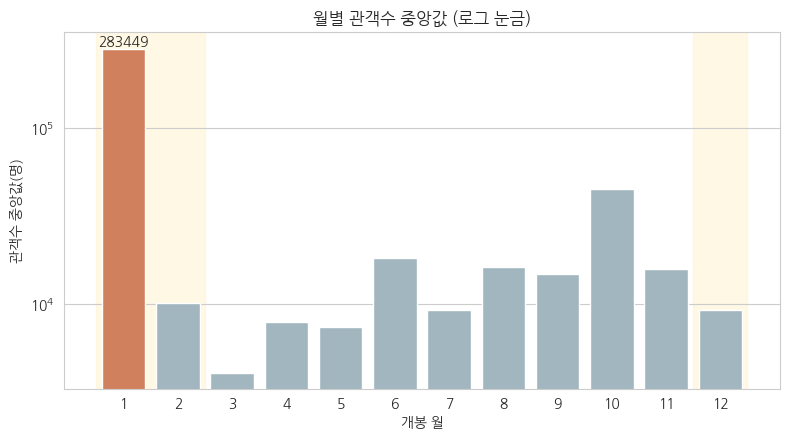

In [8]:
plt.figure(figsize=(8, 4.5))
colors = ['#E4794A' if m == 1 else '#9DB8C4' for m in month_stat.index]
ax = sns.barplot(x=month_stat.index, y=month_stat['box_median'], palette=colors)
plt.axvspan(-0.5, 1.5, color='#FFF3CD', alpha=0.5, zorder=0)
plt.axvspan(10.5, 11.5, color='#FFF3CD', alpha=0.5, zorder=0)
plt.yscale('log')
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.title('월별 관객수 중앙값 (로그 눈금)')
plt.xlabel('개봉 월')
plt.ylabel('관객수 중앙값(명)')
plt.tight_layout()
plt.show()

**그래프 분석**

12·1·2월 안에서도 1월 막대만 주황색으로 눈에 띄게 솟아 있고, 같은 배경 안의 12월·2월 막대는 배경 밖의 파란 막대들과 높이가 비슷하다. 이 그림 하나로 "겨울 전체가 아니라 1월만 특별하다"는 것이 바로 보인다.

### **3단계. 1월 효과는 매년 반복되는가**

2단계는 6년치를 합쳐서 본 결과다. 특정 연도의 대박 몇 편이 전체를 끌어올린 것인지, 6개 연도 모두에서 반복되는 패턴인지 연도별로 나눠 확인한다.

In [9]:
train['is_jan'] = train['release_month'] == 1
year_stat = train.groupby(['release_year', 'is_jan'])['box_off_num'].agg(['size', 'median']).unstack()
year_stat.columns = ['n_other', 'n_jan', 'median_other', 'median_jan']
year_stat['ratio'] = year_stat['median_jan'] / year_stat['median_other']
print(year_stat.round(1))

              n_other  n_jan  median_other  median_jan  ratio
release_year                                                 
2010               82      8       26448.5     85270.5    3.2
2011               76      4       17117.5   1371404.5   80.1
2012               83      5       13429.0    467697.0   34.8
2013               91      4       14188.0   3583886.0  252.6
2014              118      9        7584.5    479280.0   63.2
2015              111      9        6226.0    151550.0   24.3


2011 ~ 2015년의 5개 연도는 24 ~ 253배로 1월 효과가 뚜렷하다.

다만 2010년은 3.2배로 유독 약하다.

6개 연도 모두가 아니라, 2010년을 제외한 5개 연도에서 반복된다고 보는 것이 정확하다.

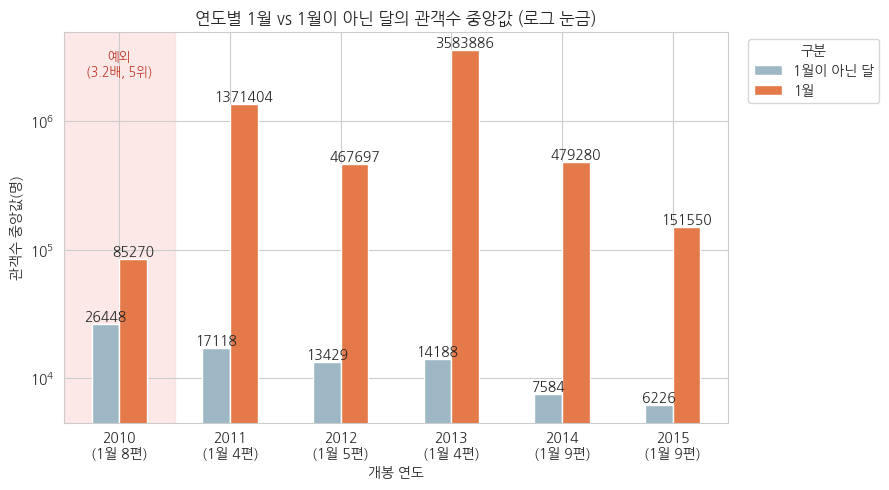

In [10]:
plot_data = year_stat[['median_other', 'median_jan']].copy()
plot_data.columns = ['1월이 아닌 달', '1월']
plot_data.index = [f'{y}\n(1월 {n}편)' for y, n in zip(year_stat.index, year_stat['n_jan'])]

fig, ax = plt.subplots(figsize=(9, 5))
plot_data.plot(kind='bar', rot=0, color=['#9DB8C4', '#E4794A'], ax=ax)
plt.axvspan(-0.5, 0.5, color='#FADBD8', alpha=0.6, zorder=0)
plt.text(0, ax.get_ylim()[1] * 0.6, '예외\n(3.2배, 5위)', ha='center', fontsize=9, color='#C0392B')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f')
plt.yscale('log')
plt.legend(title='구분', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('연도별 1월 vs 1월이 아닌 달의 관객수 중앙값 (로그 눈금)')
plt.xlabel('개봉 연도')
plt.ylabel('관객수 중앙값(명)')
plt.tight_layout()
plt.show()

**그래프 분석**

2010년만 1월 막대와 나머지 달 막대의 높이 차이가 작고, 나머지 5개 연도는 주황 막대가 파란 막대보다 뚜렷이 높다.

### **4단계. 장르 구성 때문은 아닌가**

1월 효과가 특정 장르가 1월에 몰려서 생긴 착시일 수 있다. 1월과 그 외 달의 장르 구성을 비교한다.

In [11]:
genres = ['드라마', '다큐멘터리', '멜로/로맨스', '코미디', '공포', '액션', '느와르']
sub = train[train['genre'].isin(genres)].copy()
sub['jan_label'] = np.where(sub['is_jan'], '1월', '그 외')

jan_mix = pd.crosstab(sub['jan_label'], sub['genre'], normalize='index').loc[['그 외', '1월'], genres] * 100
print(jan_mix.round(1))
print('1월 장르 구성 카이제곱 p:', round(stats.chi2_contingency(pd.crosstab(sub['jan_label'], sub['genre']))[1], 3))

genre       드라마  다큐멘터리  멜로/로맨스   코미디   공포   액션  느와르
jan_label                                          
그 외        40.7   17.3    14.7   8.9  8.1  5.2  5.2
1월         42.1   15.8    10.5  21.1  2.6  5.3  2.6
1월 장르 구성 카이제곱 p: 0.266


1월(38편)과 그 외 달(504편)의 장르 구성은 통계적으로 다르지 않다(p=0.266).

두 그룹 모두 드라마가 40% 안팎으로 가장 많다.

**따라서 1월에 관객수가 몰리는 것은 특정 장르가 1월에 몰려서 생긴 결과로 보기 어렵다.**

### **5단계. 1월 효과는 제작 규모로 설명되는가**

1월 개봉작은 애초에 대작일 수 있다.

먼저 1월 개봉작의 제작 규모 특성을 확인하고, 그다음 규모를 고정해서 다시 비교한다.



In [12]:
jan_profile = train.groupby('is_jan').agg(n_films=('title', 'size'),
                                            staff_median=('num_staff', 'median'),
                                            big_ratio=('scale',
                                                       lambda s: (s == '대(251명~)').mean() * 100))
print(jan_profile.round(1))

        n_films  staff_median  big_ratio
is_jan                                  
False       561          78.0       26.2
True         39         200.0       46.2


1월 개봉작(39편)의 스태프 수 중앙값은 200명으로 그 외 달(78명)의 2.6배다.

대규모 비율도 46.2%로 그 외 달(26.2%)보다 훨씬 높다.

1월 개봉작은 애초에 대작이다.

In [13]:
scale_stat = train.groupby(['scale', 'is_jan'], observed=True)['box_off_num'].median().unstack()
scale_stat.columns = ['그 외', '1월']
scale_stat['배수'] = scale_stat['1월'] / scale_stat['그 외']
print(scale_stat.round(1))

                  그 외         1월   배수
scale                                
소(~80명)        1782.5     2951.0  1.7
중(81~250명)    17155.0   155266.0  9.1
대(251명~)    1169546.0  1350641.5  1.2


제작 규모를 고정하고 다시 비교하면 소 1.7배, 중 9.0배, 대 1.15배다. 2단계의 24배가 대규모에서는 1.15배로 사실상 사라진다.

1월에 개봉해서 흥행한 것이 아니라, 1월에 대작을 배치하기 때문이다.

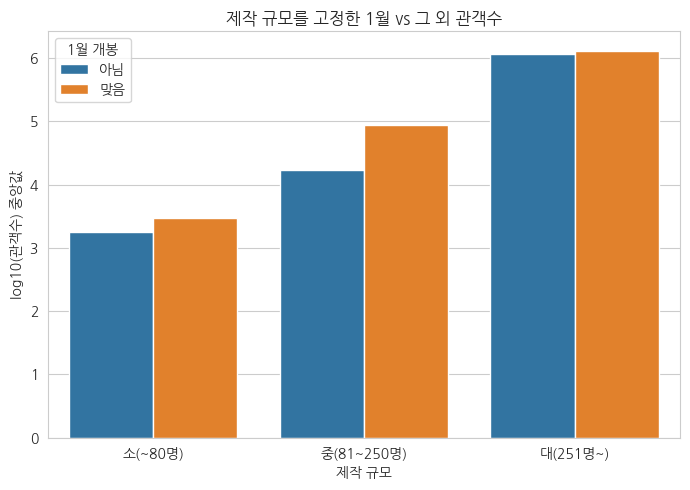

In [14]:
plt.figure(figsize=(7, 5))
sns.barplot(x='scale', y='log_box_off_num', hue='is_jan', data=train, order=scale_order,
            estimator=np.median, errorbar=None)
plt.legend(title='1월 개봉', labels=['아님', '맞음'])
plt.title('제작 규모를 고정한 1월 vs 그 외 관객수')
plt.xlabel('제작 규모')
plt.ylabel('log10(관객수) 중앙값')
plt.tight_layout()
plt.show()

**그래프 분석**

소규모와 대규모에서는 두 막대(1월/그 외)의 높이가 거의 같은데, 중규모에서만 1월 막대가 차이가 있게 높다. 24배였던 차이가 규모를 나누고 보니 소·대규모에서는 거의 사라진다는 게 한눈에 보인다.

**해석**

계절 4분류로 보면 겨울이 가장 높다. 그런데 겨울을 월별로 쪼개면 겨울 효과가 아니라 1월 효과임이 드러난다. 1월 중앙값은 나머지 달보다 24배 높고 통계적으로 유의하지만, 12·2월은 겨울이 아닌 달과 차이가 없다. **따라서 1단계에서 관찰된 "겨울 효과"는 겨울 전체의 효과가 아니라, 12·2월과는 무관한 1월만의 효과다.**


1월 효과는 2010년을 제외한 5개 연도에서 24~253배로 뚜렷했다. 여기서 2010년이 왜 예외였는지는 이 데이터로 설명할 수 없다.2013년 1월의 252.6배는 특히 크게 보이지만, 이는 1월 개봉 4편 중 흥행에 실패한 1편(1,240명)과 크게 흥행한 1편(7,166,532명)의 평균이 우연히 중앙값이 되면서 부풀려진 값이다. 편수가 4편처럼 적을 때는 중앙값이 이렇게 흔들리기 쉬우므로, 정확한 배수보다는 **"1월이 더 높다"** 는 방향에만 의미를 둔다.

1월과 그 외 달의 장르 구성은 통계적으로 다르지 않다. **즉 1월 효과는 특정 장르가 몰려서 생긴 결과가 아니다.**

**1월 개봉작은 애초에 대작이다.** 스태프 수 중앙값이 그 외 달의 2.6배이고, 절반 가까이(46.2%)가 대규모다. 제작 규모를 고정하고 다시 비교하면 소 1.7배, 중 9.0배, 대 1.15배로, 24배가 대규모에서는 1.15배로 사실상 사라진다. 1월에 개봉해서 흥행한 것이 아니라, 1월에 대작을 배치하기 때문이다.

머릿말에서 예상한 여름 효과는 데이터에서 뚜렷하게 나타나지 않았고, 대신 겨울이 아니라 1월에 관객수가 몰리는 효과가 발견되었다.

**한계**: 왈리스 검정은 정확히는 크러스컬-왈리스(Kruskal–Wallis) 검정이다. 규모를 고정해도 스태프 수는 실제 제작비가 아닌 대리 지표이며, 1월이라는 시기 자체(설 연휴 등)가 흥행에 주는 영향은 이 분석으로 분리되지 않는다.

---
# 감독. 감독 경력이 흥행을 만드는가 — 4단계 검증

**가설**: 감독의 인지도나 경력이 흥행에 영향을 줄 것이다. 단순 비교 → 교란변수 통제 → 전작 성적의 예측력 → 변수 자체의 신뢰성까지 단계적으로 검증한다.

### 0단계. 변수 구조 확인

dir_prev_bfnum(전작 평균 관객수)의 결측이 어디서 생기는지 먼저 확인한다.

In [15]:
n_missing = train['dir_prev_bfnum'].isna().sum()
n_prev_zero = (train['dir_prev_num'] == 0).sum()
print('dir_prev_bfnum 결측:', n_missing, '/ dir_prev_num==0:', n_prev_zero)

dir_prev_bfnum 결측: 0 / dir_prev_num==0: 330


dir_prev_bfnum의 결측 330개는 dir_prev_num(전작 편수)이 0인 행 330개와 정확히 일치한다. 결측이 아니라 "전작이 없어서 값이 존재할 수 없는 것"이다.

In [16]:
train['dir_prev_bfnum'] = train['dir_prev_bfnum'].fillna(0)
train['director_type'] = np.where(train['dir_prev_num'] == 0, '신인', '경력')
print(train['director_type'].value_counts())
print('경력 고유 감독 수:', train[train['director_type'] == '경력']['director'].nunique())

director_type
신인    330
경력    270
Name: count, dtype: int64
경력 고유 감독 수: 222


결측을 0으로 채운 뒤, 전작이 없는 신인 330편 / 전작이 있는 경력 270편으로 나눈다.

270편은 고유 감독 222명이 만든 영화다 (같은 감독이 여러 편 등장할 수 있으므로 편수와 감독 수가 다르다).

### **1단계. 단순 비교**

신인과 경력 감독의 관객수를 단순 비교한다. 관객수는 소수의 대박 영화가 분포를 크게 끌어올리므로 중앙값으로 비교한다.

In [17]:
raw = train.groupby('director_type')[['box_off_num', 'num_staff']].median().loc[['신인', '경력']]
print(raw)
print(raw.loc['경력'] / raw.loc['신인'])

               box_off_num  num_staff
director_type                        
신인                  3401.5       37.5
경력                222258.0      215.5
box_off_num    65.341173
num_staff       5.746667
dtype: float64


신인(3,402명)과 경력(222,258명)의 관객수 중앙값을 단순 비교하면 경력 감독이 65.3배 높다.

 그런데 스태프 수(제작 규모의 대리 지표)도 신인 38명, 경력 216명으로 5.7배 차이가 난다.

 감독 경력과 함께 제작 규모도 함께 다르므로, **관객수 차이의 원인이 경력인지 규모인지 구분해야 한다.**

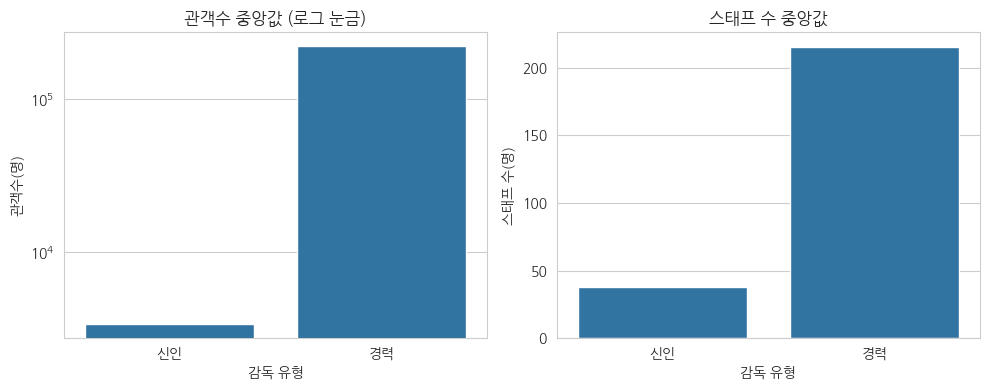

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(x=raw.index, y=raw['box_off_num'], ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_title('관객수 중앙값 (로그 눈금)')
ax[0].set_xlabel('감독 유형')
ax[0].set_ylabel('관객수(명)')
sns.barplot(x=raw.index, y=raw['num_staff'], ax=ax[1])
ax[1].set_title('스태프 수 중앙값')
ax[1].set_xlabel('감독 유형')
ax[1].set_ylabel('스태프 수(명)')
plt.tight_layout()
plt.show()

**그래프 분석**

로그 눈금이라 왼쪽 막대(관객수)의 65배 차이가 실제보다 덜 벌어져 보인다. 오른쪽 막대(스태프)도 비슷한 비율로 벌어져 있어 관객수 차이와 스태프 차이가 함께 움직인다는 걸 시각적으로 보여준다.

### **2단계. 제작 규모 고정**

제작 규모(스태프 수 기준)를 소·중·대로 나누고, 신인/경력이 맡는 규모 자체가 다른지 먼저 확인한다.

In [19]:
train['scale'] = pd.cut(train['num_staff'], [-1, 80, 250, 900],
                         labels=['소(~80명)', '중(81~250명)', '대(251명~)'])
comp = (pd.crosstab(train['director_type'], train['scale'], normalize='index') * 100).loc[['신인', '경력']]
print(comp.round(1))

scale          소(~80명)  중(81~250명)  대(251명~)
director_type                               
신인                66.4        21.5      12.1
경력                28.9        24.8      46.3


신인과 경력 감독이 맡는 제작 규모는 크게 다르다. 경력 감독은 46.3%가 대규모를 맡지만 신인은 12.1%뿐이다.
오히려 신인의 66.4%는 소규모다.

In [20]:
train['log_box_off_num'] = np.log10(train['box_off_num'])
med = train.pivot_table(index='director_type', columns='scale', values='box_off_num',
                         aggfunc='median', observed=True).loc[['신인', '경력']]
print(med.round(0))
print((med.loc['경력'] / med.loc['신인']).round(2))

scale          소(~80명)  중(81~250명)   대(251명~)
director_type                                
신인              1806.0      9323.0   885336.0
경력              1878.0     35567.0  1310895.0
scale
소(~80명)       1.04
중(81~250명)    3.81
대(251명~)      1.48
dtype: float64


제작 규모를 고정하고 같은 규모끼리 다시 비교하면 경력 감독의 관객수는 신인의 소규모 1.04배, 중규모 3.81배, 대규모 1.48배로, 1단계의 65.3배가 최대 3.8배로 줄고 소규모에서는 사실상 사라진다. **관객수 차이는 대부분 제작 규모로 설명되며**, 경력은 큰 제작을 맡게 해주는 조건에 가깝다. 다만 중규모에서는 3.81배가 남아, 규모만으로 완전히 설명되지는 않는다.

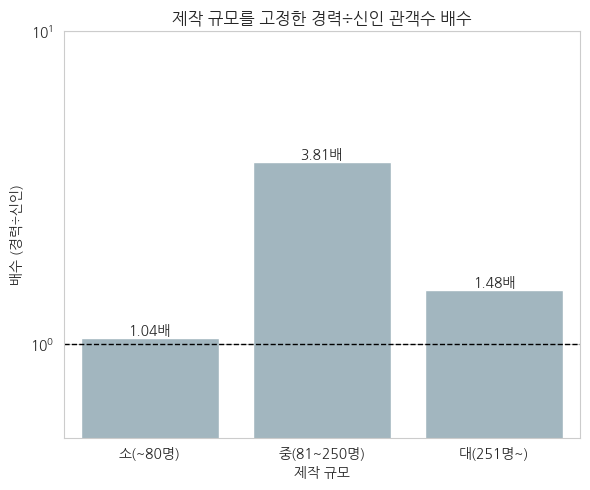

In [21]:
ratio = (med.loc['경력'] / med.loc['신인'])
plt.figure(figsize=(6, 5))
ax = sns.barplot(x=ratio.index, y=ratio.values, color='#9DB8C4')
plt.axhline(1, color='black', linestyle='--', linewidth=1)
ax.bar_label(ax.containers[0], fmt='%.2f배')
plt.yscale('log')
plt.ylim(0.5, 10)
plt.title('제작 규모를 고정한 경력÷신인 관객수 배수')
plt.ylabel('배수 (경력÷신인)')
plt.xlabel('제작 규모')
plt.tight_layout()
plt.show()

**그래프 분석**

소규모 막대만 기준선(1.0)에 거의 붙어 있고, 중규모 막대가 가장 높다. 로그 눈금이라 3.81배와 1.48배의 높이 차이가 실제보다 작게 보이므로, 막대 위에 적은 숫자로 정확한 배수를 확인해야 한다.

### **3단계. 전작 성적이 다음 흥행으로 이어지는가**

경력 감독(270편) 안에서, 전작 성적이 좋을수록 다음 작품도 흥행하는지 확인한다.

In [22]:
train_prev = train[train['dir_prev_num'] > 0].copy()
train_prev['log_prev_bfnum'] = np.log10(train_prev['dir_prev_bfnum'])
corr = train_prev['log_prev_bfnum'].corr(train_prev['log_box_off_num'])
print('상관계수:', round(corr, 3))

상관계수: 0.406


전작이 있는 270편(감독 222명)의 전작 평균 관객수와 이번 작품 관객수는 상관계수 0.406으로, **전작이 좋을수록 어느 정도 높은 경향이 있으나 예측력은 약하다.**

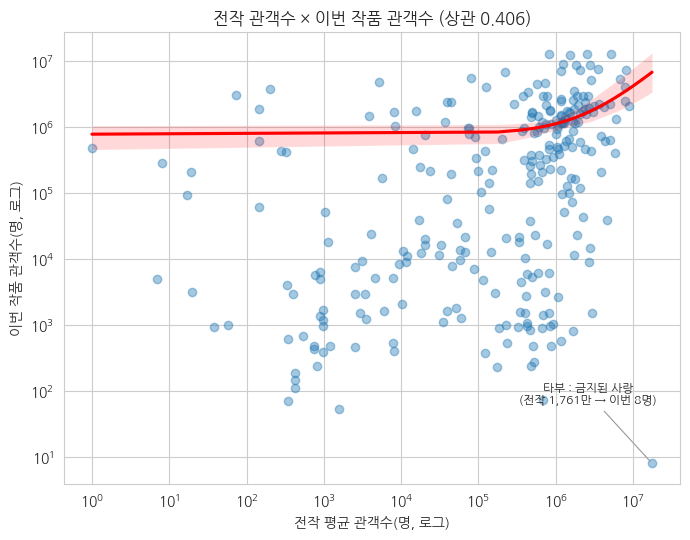

In [23]:
plt.figure(figsize=(7, 5.5))
sns.regplot(x='dir_prev_bfnum', y='box_off_num', data=train_prev,
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
plt.xscale('log')
plt.yscale('log')

outlier = train_prev[train_prev['title'] == '타부 : 금지된 사랑'].iloc[0]
plt.annotate('타부 : 금지된 사랑\n(전작 1,761만 → 이번 8명)',
             xy=(outlier['dir_prev_bfnum'], outlier['box_off_num']),
             xytext=(outlier['dir_prev_bfnum'] * 0.15, outlier['box_off_num'] * 8),
             fontsize=8.5, ha='center',
             arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8))

plt.title(f'전작 관객수 × 이번 작품 관객수 (상관 {corr:.3f})')
plt.xlabel('전작 평균 관객수(명, 로그)')
plt.ylabel('이번 작품 관객수(명, 로그)')
plt.tight_layout()
plt.show()

**그래프 분석**

오른쪽 위로 올라가는 추세선은 보이지만, 같은 전작 성적(x값)에서도 이번 작품 관객수(y값)가 위아래로 넓게 흩어져 있다. 이 흩어짐이 상관계수 0.406이 "약한 상관"인 이유를 그림으로 보여준다.

In [24]:
train_prev['prev_q'] = pd.qcut(train_prev['dir_prev_bfnum'], 4,
                                labels=['하위 25%', '중하위 25%', '중상위 25%', '상위 25%'])
grow = train_prev.groupby('prev_q', observed=True).apply(
    lambda g: (g['box_off_num'] > g['dir_prev_bfnum']).mean() * 100)
prev_med = train_prev.groupby('prev_q', observed=True)['dir_prev_bfnum'].median()
print(pd.DataFrame({'전작 중앙값': prev_med, '성장률(%)': grow}).round(1))

            전작 중앙값  성장률(%)
prev_q                    
하위 25%      1047.0    63.8
중하위 25%   142322.8    37.9
중상위 25%   813164.0    40.3
상위 25%   2270048.5    30.9


/tmp/ipykernel_36676/986223025.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grow = train_prev.groupby('prev_q', observed=True).apply(


전작 관객수를 기준으로 4분위(하위 25%~상위 25%)로 나누면, 하위 25%의 전작 관객수 중앙값은 1,047명으로 이미 바닥에 가깝다. 이 그룹의 63.8%가 전작보다 성장한 것은 실력이 아니라 더 떨어질 자리가 없는 산술적 필연(평균회귀)일 수 있다. 전체 경향은 하락이나, 중하위(37.9%)와 중상위(40.3%)는 순서가 역전되어 단조 감소는 아니다.

/tmp/ipykernel_36676/1048018165.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=grow.index, y=grow.values, palette=colors)


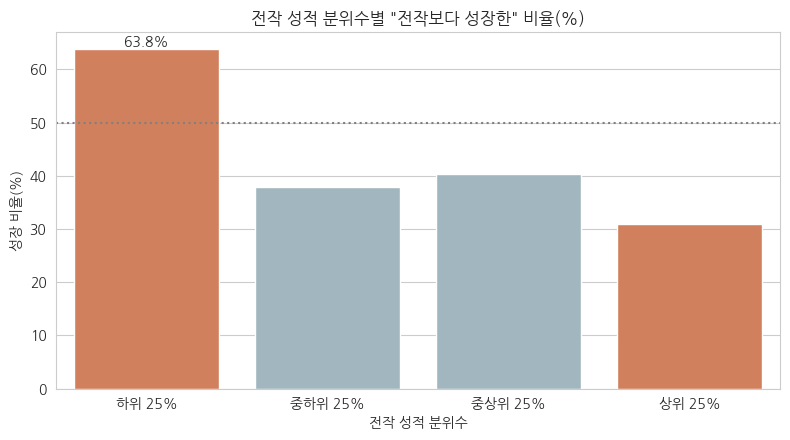

In [25]:
plt.figure(figsize=(8, 4.5))
colors = ['#E4794A' if q in ['하위 25%', '상위 25%'] else '#9DB8C4' for q in grow.index]
ax = sns.barplot(x=grow.index, y=grow.values, palette=colors)
plt.axhline(50, linestyle=':', color='gray')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.title('전작 성적 분위수별 "전작보다 성장한" 비율(%)')
plt.xlabel('전작 성적 분위수')
plt.ylabel('성장 비율(%)')
plt.tight_layout()
plt.show()

**그래프 분석**

강조색(하위·상위)의 두 막대가 각각 가장 높고 가장 낮은 위치에 있고, 회색인 가운데 두 막대(중하위·중상위)는 순서가 뒤집혀 있다(중하위<중상위). 네 막대가 매끄럽게 내려가는 계단이 아니라는 게 색 배치만으로 눈에 들어온다.

### **4단계. 이 변수를 믿어도 되나 (한계)**

앞선 1~3단계는 모두 dir_prev_num(전작 편수)이 감독의 실제 경력을 정확히 반영한다는 전제 위에 있다. 이 전제 자체를 확인한다.

In [26]:
counts = train['director'].value_counts()
multi = counts[counts >= 3].index
varies = train[train['director'].isin(multi)].groupby('director')['dir_prev_num'].nunique() > 1
print(varies.value_counts())

dir_prev_num
False    12
True      8
Name: count, dtype: int64


3편 이상 등장하는 감독 20명 중 8명(40%)만 편마다 dir_prev_num이 정상적으로 바뀌었고, 12명(60%)은 영화를 낼수록 커져야 할 값이 편마다 그대로였다. 다만 정의상 앞선 작품의 관객수를 모르면 세지 않았을 가능성이 있어, 이것만으로는 오류로 확정할 수 없다.

In [27]:
print(counts.head(5))

director
홍상수    7
우민호    4
전규환    4
신재호    4
장률     4
Name: count, dtype: int64


3편 이상 등장하는 감독 20명 중에서도 홍상수(7편)가 가장 많이 등장한다. 2위 그룹(4편)보다도 뚜렷이 많아, 편마다 dir_prev_num이 실제로 바뀌는지 확인하기에 가장 좋은 사례다.

In [28]:
hong = train[train['director'] == '홍상수'].sort_values('release_time')
print(hong[['title', 'release_time', 'dir_prev_num', 'box_off_num']].to_string(index=False))

      title release_time  dir_prev_num  box_off_num
        하하하   2010-05-05             0        57029
     옥희의 영화   2010-09-16             0        37122
       북촌방향   2011-09-08             0        46212
     다른나라에서   2012-05-31             0        31101
      우리 선희   2013-09-12             0        69122
     자유의 언덕   2014-09-04             0        39317
지금은맞고그때는틀리다   2015-09-24             1        80734


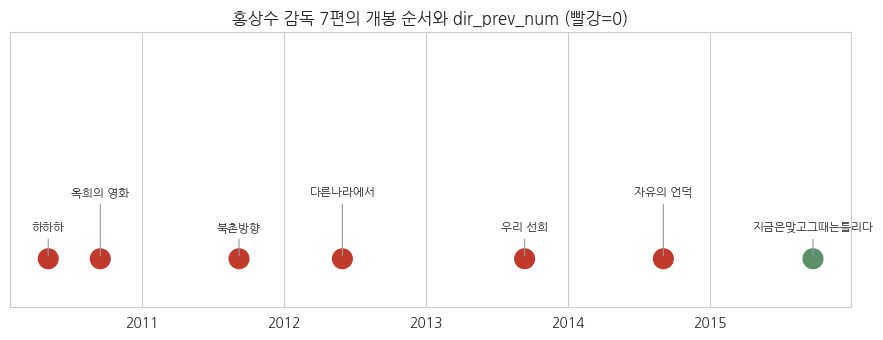

In [29]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.scatter(hong['release_time'], [1] * len(hong), s=200,
           c=['#C0392B' if v == 0 else '#5A8F69' for v in hong['dir_prev_num']])
for i, (_, r) in enumerate(hong.iterrows()):
    ax.annotate(r['title'], (r['release_time'], 1), xytext=(0, 20 if i % 2 == 0 else 45),
                textcoords='offset points', ha='center', fontsize=8.5,
                arrowprops=dict(arrowstyle='-', color='#999999', lw=0.8))
ax.set_yticks([])
ax.set_ylim(0.85, 1.7)
ax.set_title('홍상수 감독 7편의 개봉 순서와 dir_prev_num (빨강=0)')
plt.tight_layout()
plt.show()

**그래프 분석**

빨간 점 5개가 2010~2014년까지 거의 일직선으로 이어지고, 2015년에만 초록 점 하나가 있다. 점 사이 간격이 대략 1년씩이라 그동안 영화를 꾸준히 냈다는 것도 함께 보여줘서, "몰라서 못 셌다"는 반론이 힘을 잃는다.

In [30]:
matches = []
for director, g in train.groupby('director'):
    g = g.sort_values('release_time').reset_index(drop=True)
    for i in range(1, len(g)):
        prev_box = g.loc[i - 1, 'box_off_num']
        if g.loc[i, 'dir_prev_bfnum'] == prev_box and prev_box > 0:
            matches.append((director, g.loc[i, 'title'], g.loc[i - 1, 'title'], prev_box))
print('직전 작품 관객수와 정확히 일치하는 사례:', len(matches), '건')
for m in matches:
    print(m)

직전 작품 관객수와 정확히 일치하는 사례: 9 건
('권칠인', '원더풀 라디오', '참을 수 없는', np.int64(75740))
('김봉은', '나는 야한 여자가 좋다 2', '가자! 장미여관으로 2 - 갈증', np.int64(3534))
('민규동', '끝과 시작', '내 아내의 모든 것', np.int64(4598985))
('안재훈', '메밀꽃, 운수 좋은 날, 그리고 봄봄', '소중한 날의 꿈', np.int64(53235))
('우민호', '간첩', '파괴된 사나이', np.int64(1012310))
('임성구', '기적의 피아노', '법정스님의 의자', np.int64(9438))
('장진', '우리는 형제입니다', '로맨틱 헤븐', np.int64(73729))
('진승현', '어디로 갈까요?', '7월 32일', np.int64(742))
('홍상수', '지금은맞고그때는틀리다', '자유의 언덕', np.int64(39317))


"관객수를 몰라서 세지 않았다"는 설명은 성립하지 않는다. 「지금은맞고그때는틀리다」의 dir_prev_bfnum(39,317)은 같은 감독의 「자유의 언덕」 관객수(39,317)와 정확히 일치한다. 이 변수는 데이터 안의 작품을 참조해 계산되었는데, 「자유의 언덕」 앞의 다섯 편은 세어지지 않았다. 이런 사례가 홍상수를 포함해 전체 9건 확인된다(모두 dir_prev_num=1인 경우다).

**따라서 dir_prev_num은 감독의 실제 경력을 정확히 반영하지 못하는 변수로 판단한다.** 하지만 1~3단계의 결론은 이 변수가 정확하다는 전제 하에서만 유효하며, 정확한 수치(65.3배, 1.04배, 상관계수 0.406 등)는 참고치로만 다뤄야 한다. 이 확인은 3편 이상 등장하는 감독 20명에만 가능했고, 1편만 등장하는 감독(373명)은 대조할 방법이 없어 실제 문제의 규모는 더 클 수 있다.

**해석**

감독 경력과 흥행의 관계를 단순 비교하면 경력 감독이 신인보다 관객수 중앙값이 65.3배 높다. 그런데 스태프 수도 5.7배 차이가 나서, 제작 규모(스태프 수 기준)를 고정하고 다시 비교해 보았다. 이로 인해 차이가 소규모 1.04배, 중규모 3.81배, 대규모 1.48배로 줄어든다. **따라서 관객수 차이는 대부분 제작 규모로 설명되며, 경력은 큰 제작을 맡게 해주는 조건에 가깝다는 것을 확인하였다.**

경력 감독 안에서 전작 성적과 이번 작품 관객수의 관계는 상관계수 0.406으로 약하다는 것을 확인했다. 전작 관객수 기준 하위 25%(중앙값 1,047명)의 63.8%가 전작보다 성장했는데, 이는 감독의 실력 향상이 아니라 더 떨어질 자리가 없는 평균회귀일 수 있다. 다만 중하위(37.9%)와 중상위(40.3%)는 순서가 역전되어, 성장률이 매끄럽게 감소하는 것은 아니다.

물론 이 모든 결론은 전작 편수가 감독의 실제 경력을 정확히 반영한다는 전제 위에 있다. 이 데이터에서 3편 이상 등장하는 감독 20명 중 12명(60%)은 편마다 값이 그대로였다. 이에 대해 "관객수를 모르는 작품은 세지 않았을 수 있다"는 반론이 가능하지만, 가장 많이 등장하는 홍상수(7편)의 사례가 이 반론을 뒤집는다. 「지금은 맞고 그때는 틀리다」의 전작 관객수(39,317명)는 바로 앞 작품인 「자유의 언덕」의 실제 관객수와 정확히 일치한다. 즉 「자유의 언덕」의 관객수는 이미 알고 있었다는 뜻인데도, 그보다 앞선 5편(관객수가 모두 데이터에 있음)은 세어지지 않았다. 이런 사례가 전체 9건 확인된다. 따라서 "관객수를 몰라서 세지 않았다"는 설명은 성립하지 않는다.

**따라서 편수를 의미하는 dir_prev_num은 감독의 실제 경력을 정확히 반영하지 못하는 변수로 판단한다. **규모를 맞추면 경력 격차가 줄어든다는 방향성은 참고할 수 있으나, 65.3배·1.04배·상관계수 0.406 같은 정확한 수치는 참고치로만 다뤄야 한다.

**한계**: 이 신뢰도 확인은 3편 이상 등장하는 감독 20명에만 가능했고, 1편만 등장하는 감독(373명)은 대조할 방법이 없어 실제 문제의 규모는 더 클 수 있다. 스태프 수 역시 실제 제작비가 아닌 규모의 대리 지표이고, 소·중·대 경계(80명·250명)는 자의적인 기준이다.

---
# **관람등급. 청소년 관람불가 비율은 어떻게 변해왔는가**

**가설**: 연도가 지날수록 청소년 관람불가 비율이 늘어날 것이다. 특히 멜로/로맨스 장르에서 그 변화가 두드러질 것으로 예상했다.

### **0단계. 변수 확인**

관람등급과 개봉 연도가 결측 없이 잘 채워져 있는지 확인한다.

In [31]:
rating_order = ['전체 관람가', '12세 관람가', '15세 관람가', '청소년 관람불가']
train['is_adult'] = train['screening_rat'] == '청소년 관람불가'

print('결측:', train['screening_rat'].isna().sum())
print(train['screening_rat'].value_counts().loc[rating_order])
print(train['release_year'].value_counts().sort_index())

결측: 0
screening_rat
전체 관람가       92
12세 관람가     102
15세 관람가     202
청소년 관람불가    204
Name: count, dtype: int64
release_year
2010     90
2011     80
2012     88
2013     95
2014    127
2015    120
Name: count, dtype: int64


결측 없이 600편 모두 등급이 기록되어 있다. 등급은 전체 관람가 92편, 12세 102편, 15세 202편, 청소년 관람불가 204편이다.

### **1단계. 연도별 청소년 관람불가 비율**

연도별 등급 구성 중 청소년 관람불가 비율의 추이를 확인한다.

In [32]:
rating_ratio = pd.crosstab(train['release_year'], train['screening_rat'], normalize='index')[rating_order] * 100
print(rating_ratio.round(1))

screening_rat  전체 관람가  12세 관람가  15세 관람가  청소년 관람불가
release_year                                     
2010             20.0     17.8     30.0      32.2
2011             23.8     17.5     38.8      20.0
2012              9.1     20.5     50.0      20.5
2013             12.6     13.7     33.7      40.0
2014             14.2     17.3     27.6      40.9
2015             14.2     15.8     27.5      42.5


2010년은 32.2%로 이미 높았다가 2011 ~ 2012년에 20%대로 떨어진 뒤, 2013년부터 40% 이상으로 올라 유지된다. 2011 ~ 2012년부터 "늘었다"고 서술하면 2010년이 빠져 단조 증가처럼 보이지만, 실제로는 2010년(32.2%) → 2011 ~ 2012년(20%대) → 2013년 이후(40%대)로 이어지는 V자에 가까운 모양이다. **단조 증가가 아니라 2013년을 경계로 수준이 이동한 형태로 보는 것이 정확하다.**

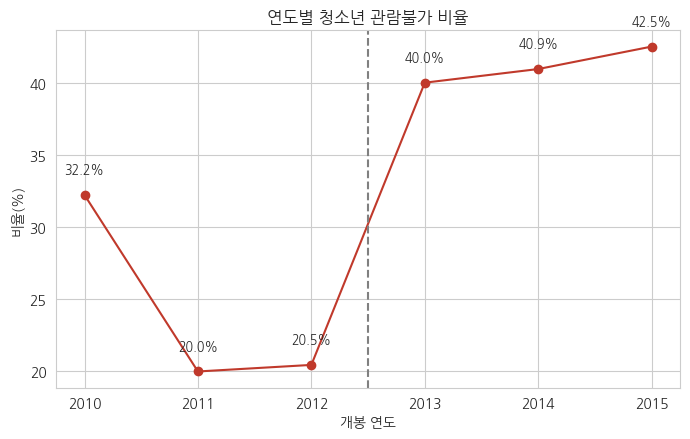

In [33]:
plt.figure(figsize=(7, 4.5))
plt.plot(rating_ratio.index, rating_ratio['청소년 관람불가'], marker='o', color='#C0392B')
for y, v in rating_ratio['청소년 관람불가'].items():
    plt.text(y, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.axvline(2012.5, linestyle='--', color='gray')
plt.title('연도별 청소년 관람불가 비율')
plt.xlabel('개봉 연도')
plt.ylabel('비율(%)')
plt.tight_layout()
plt.show()

**그래프 분석**

점선(2012.5년) 왼쪽에서 2010년만 유독 튀어 있고 2011·2012년은 낮다. 점선 오른쪽부터는 40% 안팎에서 계속 유지된다. 이 선 그래프 하나로 "단조 증가가 아니라 2010년이 예외이고 2013년부터 수준이 바뀌었다"는 게 바로 보인다.

### **2단계. 장르별 청소년 관람불가 비율의 변화**

전체 비율의 변화가 어떤 장르에서 온 것인지 확인한다. 연도별로 나누면 장르당 편수가 너무 적어지므로 2010 ~ 2012년 / 2013 ~ 2015년 두 기간으로 나눈다.

In [34]:
train['period'] = np.where(train['release_year'] <= 2012, '2010~2012년', '2013~2015년')
main_genres = ['드라마', '다큐멘터리', '멜로/로맨스', '코미디', '공포', '액션', '느와르']

count = pd.crosstab(train['genre'], train['period']).loc[main_genres]
rate = (train.groupby(['genre', 'period'])['is_adult'].mean().unstack() * 100).loc[main_genres]
change = pd.DataFrame({'2010~2012년': rate['2010~2012년'], '2013~2015년': rate['2013~2015년'],
                       '변화폭': rate['2013~2015년'] - rate['2010~2012년']}).sort_values('변화폭', ascending=False)

change['n'] = count['2010~2012년'] + count['2013~2015년']
change['group'] = np.where(change['n'] < 20, '20편 미만',
                    np.where(change['변화폭'] >= 10, '20편 이상, +10%p 이상', '20편 이상, +10%p 미만'))
change['label'] = [f"{g} ({count.loc[g, '2010~2012년']}/{count.loc[g, '2013~2015년']}편)" for g in change.index]
print(change.round(1))

        2010~2012년  2013~2015년   변화폭    n             group            label
genre                                                                       
멜로/로맨스        25.9        76.5  50.5   78  20편 이상, +10%p 이상  멜로/로맨스 (27/51편)
코미디            6.9        41.7  34.8   53  20편 이상, +10%p 이상     코미디 (29/24편)
드라마           26.5        42.9  16.4  221  20편 이상, +10%p 이상   드라마 (102/119편)
느와르           63.6        68.8   5.1   27  20편 이상, +10%p 미만     느와르 (11/16편)
다큐멘터리          0.0         1.9   1.9   93  20편 이상, +10%p 미만   다큐멘터리 (40/53편)
공포            53.3        51.9  -1.5   42  20편 이상, +10%p 미만      공포 (15/27편)
액션            50.0        28.6 -21.4   28  20편 이상, +10%p 미만      액션 (14/14편)



상위 7개 장르(전체가 아니라 20편 이상인 주요 장르)만 봤을 때, 멜로/로맨스가 25.9%→76.5%로 변화폭이 가장 크고(+50.6%p), 코미디(+34.8%p)·드라마(+16.4%p)가 뒤를 잇는다. 공포·느와르는 원래도 절반 이상이라 큰 변화가 없고, 액션은 오히려 줄었다(−21.4%p).

In [35]:
from scipy import stats
rows = []
for g in main_genres:
    sub = train[train['genre'] == g]
    early = sub[sub['period'] == '2010~2012년']['is_adult']
    late = sub[sub['period'] == '2013~2015년']['is_adult']
    p = stats.fisher_exact([[early.sum(), (~early).sum()], [late.sum(), (~late).sum()]])[1]
    rows.append({'genre': g, 'early': f'{early.sum()}/{len(early)}', 'late': f'{late.sum()}/{len(late)}', 'p값': round(p, 4)})
print(pd.DataFrame(rows).to_string(index=False))

 genre  early   late     p값
   드라마 27/102 51/119 0.0116
 다큐멘터리   0/40   1/53 1.0000
멜로/로맨스   7/27  39/51 0.0000
   코미디   2/29  10/24 0.0035
    공포   8/15  14/27 1.0000
    액션   7/14   4/14 0.4401
   느와르   7/11  11/16 1.0000


이 변화가 우연인지 피셔 정확검정으로 확인하면, 멜로/로맨스(p<0.001)·코미디(p=0.004)·드라마(p=0.012)는 통계적으로 유의하다. 공포·느와르·액션은 유의하지 않다(원래도 변화가 작았거나 편수가 적어서다).

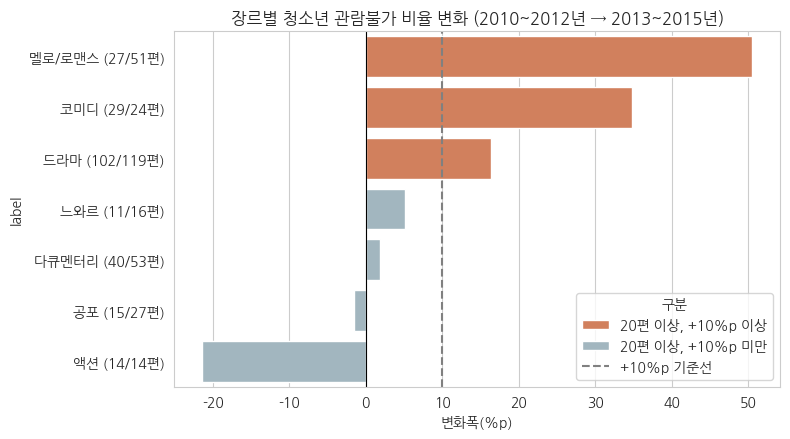

In [36]:
palette = {'20편 이상, +10%p 이상': '#E4794A', '20편 이상, +10%p 미만': '#9DB8C4', '20편 미만': '#C8C8C8'}
change['n'] = count['2010~2012년'] + count['2013~2015년']
change['group'] = np.where(change['n'] < 20, '20편 미만',
                    np.where(change['변화폭'] >= 10, '20편 이상, +10%p 이상', '20편 이상, +10%p 미만'))
change['label'] = [f"{g} ({count.loc[g, '2010~2012년']}/{count.loc[g, '2013~2015년']}편)" for g in change.index]

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x='변화폭', y='label', hue='group', data=change, palette=palette, dodge=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline(10, linestyle='--', color='gray', label='+10%p 기준선')
plt.legend(title='구분', loc='lower right')
plt.title('장르별 청소년 관람불가 비율 변화 (2010~2012년 → 2013~2015년)')
plt.xlabel('변화폭(%p)')
plt.tight_layout()
plt.show()

**그래프 분석**

오른쪽으로 뻗은 주황 막대(멜로/로맨스, 코미디, 드라마)가 +10%p 점선을 넘고, 회색·파랑 막대는 그 안쪽에 머문다. 액션만 유일하게 0 왼쪽(감소)으로 뻗어 있어 다른 장르와 반대 방향이라는 게 바로 보인다.

### 가장 변화가 큰 멜로/로맨스를 기준으로 더 자세히 확인한다.

In [37]:
romance = train[train['genre'] == '멜로/로맨스']
year_stat = romance.groupby('release_year')['is_adult'].agg(n='size', adult_n='sum')
year_stat['adult_pct'] = year_stat['adult_n'] / year_stat['n'] * 100
print(year_stat.round(1))

               n  adult_n  adult_pct
release_year                        
2010          11        5       45.5
2011           7        1       14.3
2012           9        1       11.1
2013          12        7       58.3
2014          18       15       83.3
2015          21       17       81.0


멜로/로맨스의 청소년 관람불가 비율은 2010년 이후 계속 올라, 2015년에는 18편 중 15편(83%)에 이른다.

In [38]:
m2014 = romance[(romance['release_year'] == 2014) & (romance['is_adult'])]
print('2014년 멜로/로맨스 청소년 관람불가:', len(m2014), '편')
print(m2014[['title', 'box_off_num', 'num_staff']].sort_values('box_off_num').to_string(index=False))
print('스태프 수 중앙값(청불):', m2014['num_staff'].median(),
      '/ 그 외 등급(2013~2015):', train[(train['genre']=='멜로/로맨스') & (train['period']=='2013~2015년') & (~train['is_adult'])]['num_staff'].median())

2014년 멜로/로맨스 청소년 관람불가: 15 편
            title  box_off_num  num_staff
          젊은 엄마 2            1          0
             러브멘토           54          0
         캠퍼스 S 커플          891         66
   나는 야한 여자가 좋다 2         1250         26
       가자, 장미여관으로         1533         26
              중독애         1547         24
               열애         1564         42
             먹이사슬         2070          0
               관계         2146         57
         여배우는 너무해         2673        129
          여배우 공작단         2729          7
가자! 장미여관으로 2 - 갈증         3534         27
청춘학당 : 풍기문란 보쌈 야사         3772        100
         배꼽과 무릎사이         7448         18
            마담 뺑덕       471248        450
스태프 수 중앙값(청불): 26.0 / 그 외 등급(2013~2015): 247.0


2014년 멜로/로맨스 18편 중 15편이 청소년 관람불가다. 제목을 보면 성인물 계열로 추정되는 제목이 다수이고, 15편 중 14편의 관객수가 1,000~7,500명대로 매우 작다. 이 15편의 스태프 수 중앙값(26명)은 같은 시기 다른 등급 멜로/로맨스(247명)의 10분의 1이다. **이는 저예산 성인물 장르가 "청소년 관람불가" 통계에 함께 집계되고 있을 가능성을 보여준다. 다만 제목과 스태프 수로 추정한 것이라 확정은 아니다.**

### **3단계. 장르 구성 때문은 아닌가**

청소년 관람불가 비율의 증가(24.4%→41.2%)가 장르 자체의 변화(장르 안에서 청불 비율 상승) 때문인지, 장르 구성 자체가 바뀌어서(청불이 많은 장르가 늘어서) 생긴 것인지 나눠 확인한다.

In [39]:
mix = pd.crosstab(train['genre'], train['period'], normalize='columns') * 100
rate_all = train.groupby(['genre', 'period'])['is_adult'].mean().unstack().fillna(0)

actual_early = train[train['period'] == '2010~2012년']['is_adult'].mean() * 100
actual_late = train[train['period'] == '2013~2015년']['is_adult'].mean() * 100
fixed_mix = (mix['2010~2012년'] / 100 * rate_all['2013~2015년']).sum() * 100

result = pd.Series({'2010~2012년\n(실제)': actual_early,
                     '2013~2015년\n(장르 구성을 2010~2012년과 같게 가정)': fixed_mix,
                     '2013~2015년\n(실제)': actual_late})
print(result.round(1))

2010~2012년\n(실제)                          24.4
2013~2015년\n(장르 구성을 2010~2012년과 같게 가정)    39.0
2013~2015년\n(실제)                          41.2
dtype: float64


장르 구성을 2010 ~ 2012년과 똑같이 고정해도(가상값) 청소년 관람불가 비율은 39.0%까지 오른다. 실제 2013 ~ 2015년(41.2%)과 거의 같다. 즉 실제 상승분(24.4%→41.2%, +16.8%p) 중 대부분(+14.6%p)은 같은 장르 안에서 청불 비율이 오른 것이고, 장르 구성 변화로 설명되는 부분(+2.2%p)은 작다.

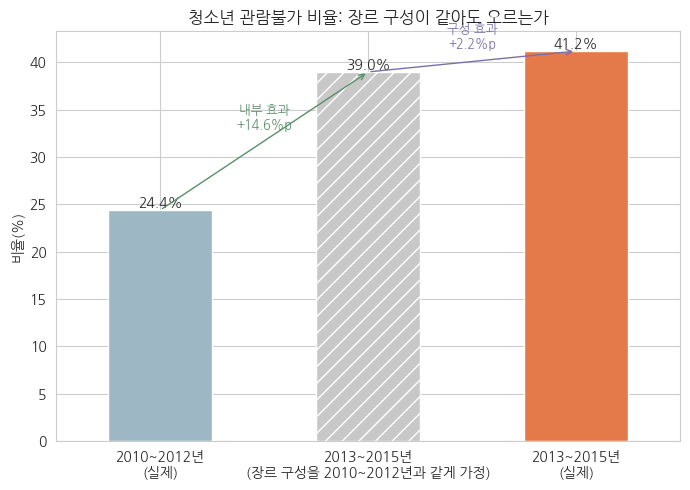

In [40]:
plt.figure(figsize=(7, 5))
ax = result.plot(kind='bar', rot=0, color=['#9DB8C4', '#C8C8C8', '#E4794A'],
                  hatch=[None, '//', None])
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.annotate('', xy=(1, 39.0), xytext=(0, 24.4), arrowprops=dict(arrowstyle='->', color='#5A8F69'))
plt.text(0.5, 33, '내부 효과\n+14.6%p', color='#5A8F69', ha='center', fontsize=9)
plt.annotate('', xy=(2, 41.2), xytext=(1, 39.0), arrowprops=dict(arrowstyle='->', color='#7B6FA8'))
plt.text(1.5, 41.5, '구성 효과\n+2.2%p', color='#7B6FA8', ha='center', fontsize=9)
plt.title('청소년 관람불가 비율: 장르 구성이 같아도 오르는가')
plt.ylabel('비율(%)')
plt.tight_layout()
plt.show()

**그래프 분석**

가운데 막대만 빗금이 있어 "실제 값이 아니라 가정값"이라는 게 구분된다. 첫째-둘째 막대 사이의 초록 화살표(+14.6%p)가 둘째-셋째 막대 사이의 보라 화살표(+2.2%p)보다 훨씬 길어서, 상승의 대부분이 내부 효과에서 온다는 게 한눈에 보인다.

**해석**

연도별 청소년 관람불가 비율은 2010년 32.2%로 이미 높았다가 2011~2012년에 20%대로 떨어진 뒤, 2013년부터 40% 이상으로 올라 유지된다. 단조 증가가 아니라 2013년을 경계로 수준이 이동한 형태다.

이 변화는 상위 7개 장르 중 멜로/로맨스(+50.6%p)·코미디(+34.8%p)·드라마(+16.4%p)에서 통계적으로 유의하게(p<0.05) 나타났고, 공포·느와르는 원래도 비율이 높아 변화가 적었으며 액션은 오히려 줄었다(−21.4%p). 이 방향은 기간을 나누는 경계를 2011~2013년 중 어디로 옮겨도 바뀌지 않는다.

가장 변화가 큰 멜로/로맨스를 보면, 2014년 청소년 관람불가로 분류된 18편 중 15편의 관객수가 1,000~7,500명대이고 스태프 수 중앙값(26명)도 다른 등급(247명)의 10분의 1이다. 제목도 성인물 계열로 추정되는 경우가 많아, 저예산 성인물이 이 통계에 함께 집계되고 있을 가능성이 있다. 다만 이는 제목과 스태프 수로 추정한 것이라 확정은 아니다.

전체 비율 상승(24.4%→41.2%, +16.8%p)을 장르 구성 효과와 내부 효과로 나누면, 장르 구성을 2010~2012년과 동일하게 고정해도 39.0%까지 오른다. 즉 상승분의 대부분(+14.6%p)은 같은 장르 안에서 청불 비율이 오른 것이고, 장르 구성 변화로 설명되는 부분(+2.2%p)은 작다.

**한계**: 왜 2013년에 수준이 바뀌었는지, 왜 장르 내부에서 청불 비율이 올랐는지는 이 데이터로 확인할 수 없다. 2010년이 예외적으로 높았던 이유도 설명할 수 없다. 2014년 멜로/로맨스의 "성인물" 추정은 제목·스태프 수라는 간접 지표에 근거한 것으로, 실제 내용 등급 분류 기준을 확인한 것은 아니다.